In [14]:
import numpy as np
import matplotlib.pyplot as plt

In [15]:
# parameters
length = 1.0
nx = 50              # spatial points
dx = length / nx
alpha = 0.01         # thermal diffusivity
dt = 0.0005
steps = 400

In [16]:
# stability condition
print("alpha*dt/dx^2 =", alpha*dt/dx**2)

alpha*dt/dx^2 = 0.0125


In [17]:
# initial temperature distribution

u = np.zeros(nx)
u[int(nx/2)] = 100   # heat spike in middle

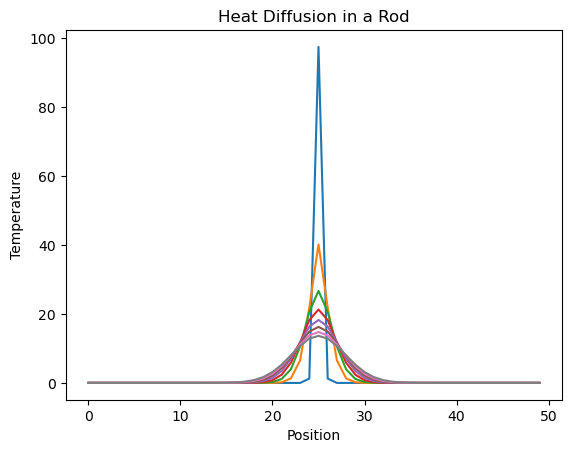

In [18]:
plt.figure()

for step in range(steps):
    
    u_new = u.copy()
    
    for i in range(1, nx-1):
        u_new[i] = u[i] + alpha*dt/dx**2 * (u[i+1] - 2*u[i] + u[i-1])
    
    u = u_new
    
    if step % 50 == 0:
        plt.plot(u)

plt.title("Heat Diffusion in a Rod")
plt.xlabel("Position")
plt.ylabel("Temperature")
plt.show()

In [19]:
import numpy as np
import plotly.graph_objects as go

# grid size
nx, ny = 50, 50
dx = dy = 1

# thermal diffusivity
alpha = 0.2

# time step
dt = 0.1
steps = 120

# temperature grid
u = np.zeros((nx, ny))

# initial heat spike in center
u[nx//2, ny//2] = 100

frames = []

for step in range(steps):

    u_new = u.copy()

    # finite difference update
    for i in range(1, nx-1):
        for j in range(1, ny-1):

            laplacian = (
                u[i+1,j] + u[i-1,j] +
                u[i,j+1] + u[i,j-1] -
                4*u[i,j]
            )

            u_new[i,j] = u[i,j] + alpha*dt*laplacian

    u = u_new

    if step % 3 == 0:
        frames.append(
            go.Frame(
                data=[go.Surface(z=u)]
            )
        )

# initial plot
fig = go.Figure(
    data=[go.Surface(z=u)],
    frames=frames
)

fig.update_layout(
    title="2D Heat Equation Simulation",
    scene=dict(
        zaxis_title="Temperature",
        xaxis_title="X",
        yaxis_title="Y"
    ),
    width=800,
    height=700,
    updatemenus=[{
        "type": "buttons",
        "buttons":[
            {
                "label":"Play",
                "method":"animate",
                "args":[None]
            }
        ]
    }]
)

fig.show()